# Homework 5
## By Ram Kakinada
## ECE 580C7

In [83]:
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.utils.data import Subset
import numpy as np

device = torch.device('cuda:0') # use the first GPU on this system


In [84]:
transform = transforms.Compose([
    transforms.ToTensor()])
dataset_train = datasets.MNIST(root='data',train=True,download=True,transform=transform)
dataset_val = datasets.MNIST(root='data',train=False,download=True, transform=transform)

In [97]:
model = nn.Sequential(
    nn.Conv2d(1,16,3,padding =1),
    nn.ReLU(),
    nn.Conv2d(16,16,3,padding =1),
    nn.ReLU(),
    nn.Conv2d(16,1,3,padding=1),
    nn.Tanh()
    )

In [98]:
loss_fn = nn.L1Loss()
model=model.to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

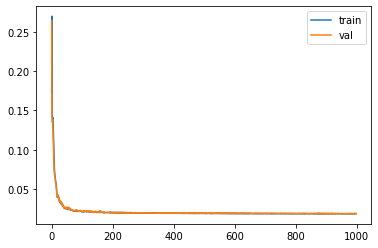

In [87]:
# load a limited set of the training data onto the GPU/
nTrain = 1000
y = dataset_train.data.unsqueeze(1).float().to(device)/255.
y=y[0:1000]
x = 0.8*y + 0.2*torch.randn_like(y)

len(x)
len(y)

# load entire validation set onto the GPU
y_val = dataset_val.data.unsqueeze(1).float().to(device)/255.
y_val = y_val[0:1000]
x_val = 0.8*y_val + 0.2*torch.randn_like(y_val)


loss_train_vec = []
loss_val_vec = []

# training loop
n_epochs = 1000
for epoch in range(1,n_epochs):
    yhat = model(x)

    loss = loss_fn(yhat,y)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    loss_train_vec += [loss.item()]
    
    # calculate validation loss
    with torch.no_grad():
        yhat_val = model(x_val)
        loss_val = loss_fn(yhat_val,y_val)
        
    loss_val_vec   += [loss_val.item()]
    
    # plot training/validation loss curves
    clear_output(wait=True)
    plt.plot(loss_train_vec)
    plt.plot(loss_val_vec)
    plt.legend(['train','val'])
    plt.show()

### Validation Set Examples

#### Ground Truth

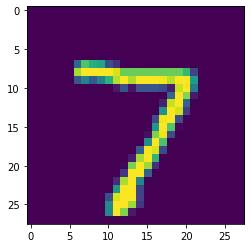

In [25]:
plt.imshow(y_val[0,0].cpu())

#### Noisy Input

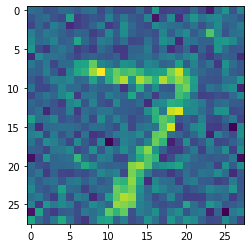

In [26]:
plt.imshow(x_val[0,0].cpu())

#### Denoised Output

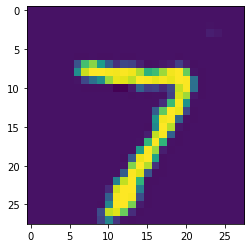

In [27]:
yhat_val = model(x_val)
yhat_val=yhat_val.cpu().detach().numpy()
plt.imshow(yhat_val[0,0])

### Test set

#### Ground Truth

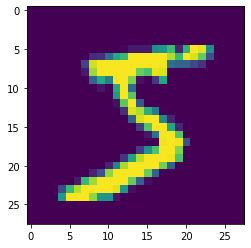

In [28]:
plt.imshow(y[0,0].cpu())

#### Noisy Input

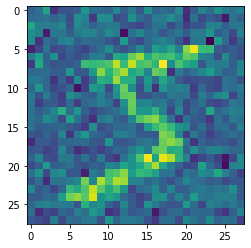

In [29]:
plt.imshow(x[0,0].cpu())

#### Denoised Output

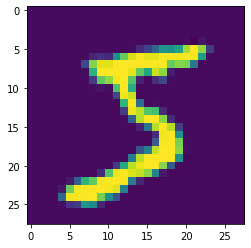

In [30]:
yhat = model(x)
yhat=yhat.cpu().detach().numpy()
plt.imshow(yhat[0,0])

### Discussion
#### Overall, I think we can say that the model is generalizing very nicely as looking at the error plots, both the plots for the validation and training set are almost identical which tells us that there is not really any overfitting going on. In addition to that the error for both the training and the validation sets were quite close to zero and the error seemed to be stable for quite a while indicating there are not really any more losses in error to be found. Visually speaking, the denoised image is almost indistinguishable from the ground truth image in both the validation and training sets other than some slight discoloration of the background. 

## Extra Credit

### Weiner Filter

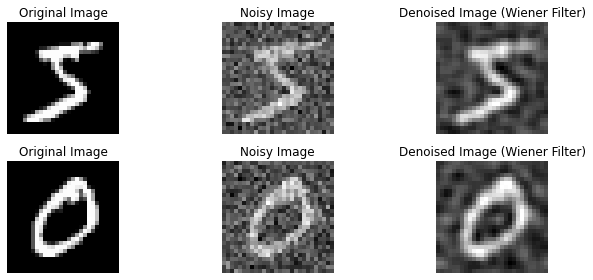

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from skimage import restoration, img_as_float

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Parameters
num_images = 2  # Number of images to process
noise_factor = 0.2  # Noise factor
image_size = 28  # MNIST image size

# Initialize arrays for noisy and original images
noisy_images = []
original_images = []

# Add noise to images
for i in range(num_images):
    # Get image and convert to NumPy array
    y = mnist_data[i][0].squeeze().numpy()  # Shape: (28, 28)
    original_images.append(y)

    # Add noise using the formula x = 0.8*y + 0.2*torch.randn_like(y)
    noise = noise_factor * torch.randn_like(torch.tensor(y))
    x = 0.8 * y + noise.numpy()  # Shape: (28, 28)
    noisy_images.append(x)

# Convert lists to NumPy arrays
original_images = np.array(original_images)
noisy_images = np.array(noisy_images)

#cPoint Spread Function
psf = np.ones((3, 3)) / 9 

# Initialize an array to hold the deconvolved images
deconvolved_images = np.zeros_like(noisy_images)

# Apply Wiener filter to each noisy image
for i in range(noisy_images.shape[0]):
    deconvolved_images[i] = restoration.wiener(noisy_images[i], psf=psf, balance=0.1)

# Plot original, noisy, and deconvolved images
fig, axes = plt.subplots(num_images, 3, figsize=(10, 2 * num_images))
for i in range(num_images):
    axes[i, 0].imshow(original_images[i], cmap='gray')
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(noisy_images[i], cmap='gray')
    axes[i, 1].set_title('Noisy Image')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(deconvolved_images[i], cmap='gray')
    axes[i, 2].set_title('Denoised Image (Wiener Filter)')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

### TV Filter

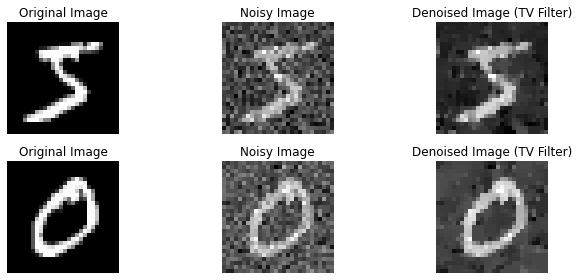

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from skimage import restoration, img_as_float

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Parameters
num_images = 2  # Number of images to process
noise_factor = 0.2  # Noise factor
image_size = 28  # MNIST image size

# Initialize arrays for noisy and original images
noisy_images = []
original_images = []

# Add noise to images
for i in range(num_images):
    # Get image and convert to NumPy array
    y = mnist_data[i][0].squeeze().numpy()  # Shape: (28, 28)
    original_images.append(y)

    # Add noise using the formula x = 0.8*y + 0.2*torch.randn_like(y)
    noise = noise_factor * torch.randn_like(torch.tensor(y))
    x = 0.8 * y + noise.numpy()  # Shape: (28, 28)
    noisy_images.append(x)

# Convert lists to NumPy arrays
original_images = np.array(original_images)
noisy_images = np.array(noisy_images)


# Initialize an array to hold the deconvolved images
deconvolved_images = np.zeros_like(noisy_images)

# Apply Wiener filter to each noisy image
for i in range(noisy_images.shape[0]):
    deconvolved_images[i] = restoration.denoise_tv_chambolle(noisy_images[i], weight=0.1)

# Plot original, noisy, and deconvolved images
fig, axes = plt.subplots(num_images, 3, figsize=(10, 2 * num_images))
for i in range(num_images):
    axes[i, 0].imshow(original_images[i], cmap='gray')
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(noisy_images[i], cmap='gray')
    axes[i, 1].set_title('Noisy Image')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(deconvolved_images[i], cmap='gray')
    axes[i, 2].set_title('Denoised Image (TV Filter)')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

### Dsicussion
#### I will be comparing all of the the images from the ssci-kit filters visually. I am primiarily comapring the abnility of these fitlers against the convolutional filters that I had in the previous portion of this assignment. I am largely comparing the ground truth to the Denoised image to evaluate the performace of the fiters. Visually, it is very easy to see that both the TV filter and the Wiener filter perform worse than our 3 layer convolutional filter as the denoised image is almost indistinguishable from the ground truth in our neural network, however there are quite a few artifacts leftover from wiener and TV filters. 

### CIFAR image database

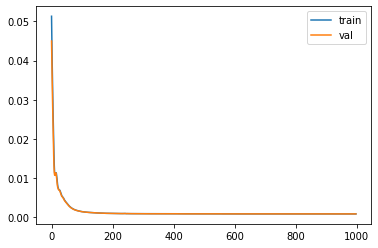

In [100]:
# Load CIFAR-10 dataset
transform = transforms.Compose([transforms.ToTensor()])
dataset_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataset_val = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Limit the training data 
nTrain = 1000
y = torch.stack([dataset_train[i][0] for i in range(nTrain)]).float().to(device)
y = y / 255.0  # Normalize
x = 0.8 * y + 0.2 * torch.randn_like(y)  # Add noise

# Limit the validation data 
y_val = torch.stack([dataset_val[i][0] for i in range(nTrain)]).float().to(device)
y_val = y_val / 255.0  # Normalize to [0,1]
x_val = 0.8 * y_val + 0.2 * torch.randn_like(y_val)  # Add noise

loss_train_vec = []
loss_val_vec = []

model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 3, kernel_size=3, padding=1),
    nn.Tanh()
)
model = model.to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
n_epochs = 1000
for epoch in range(1,n_epochs):
    yhat = model(x)

    loss = loss_fn(yhat,y)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    loss_train_vec += [loss.item()]
    
    # calculate validation loss
    with torch.no_grad():
        yhat_val = model(x_val)
        loss_val = loss_fn(yhat_val,y_val)
        
    loss_val_vec   += [loss_val.item()]
    
    # plot training/validation loss curves
    clear_output(wait=True)
    plt.plot(loss_train_vec)
    plt.plot(loss_val_vec)
    plt.legend(['train','val'])
    plt.show()

### Discussion
#### This was a suprising reuslt to see, the model that we created acutally worked better on the CIFAR10 data than it did on the MNIST data set. Under the same conditions and with the same noise added to the CIFAR10 data set, the validation set matched the training set and far outperformed the MNSIT data set almost driving the error down to zero.